In [ ]:
# Case Study-IMDB Sentiment Detection
# --------------------------------------
# 1. Load the the Given Data
# 2. Exploratory Data Analysis
# 3. Segregate the inputs and output
# 4. Split the sata into Training and Testing
# 5. Data Transformation-
#         a.Text Preprocessing(Special chart,stop words,lower case, lemmatization etc)
#         b.Text Vectorization-converting text to numerical vector-bag of words 
# 6. Model Building with training dataset
# 7. Prediction with test dataset
# 8. Evaluate the model performance

In [2]:
import os
import numpy as np  # numerical/mathematical calculation
import pandas as pd # data manipulation
import matplotlib.pyplot as plt
import seaborn as sns # stats and visualisation
dataset=pd.read_csv("IMDB_dataset.csv")
dataset.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


<Axes: xlabel='Count', ylabel='Words'>

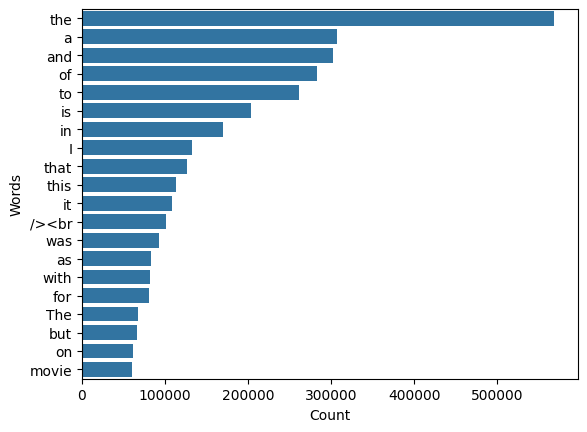

In [4]:
from collections import Counter
words=" ".join(dataset['review'].values).split()
words_count=Counter(words)
common_words=words_count.most_common(20)
common_words_df=pd.DataFrame(common_words,columns=['Words','Count'])
sns.barplot(data=common_words_df,x='Count',y="Words")

## Step 3- Segregate inputs(x) and outpt(y)

In [6]:
x=dataset[["review"]]
y=dataset[['sentiment']]
x

,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."
...,...
49995,I thought this movie did a down right good job...
49996,"Bad plot, bad dialogue, bad acting, idiotic di..."
49997,I am a Catholic taught in parochial elementary...
49998,I'm going to have to disagree with the previou...


y

# Split data into train and test

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2,stratify=y)

In [8]:
y_train.value_counts()

sentiment
negative     20000
positive     20000
Name: count, dtype: int64

In [9]:
y_test.value_counts()

sentiment
negative     5000
positive     5000
Name: count, dtype: int64

# Data Preparation on Training Data

In [10]:
dataset['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [11]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
def clean(doc):
    regex="[^a-zA-Z]"
    doc=re.sub(regex," ",doc)
    doc=doc.lower()
    tokens=nltk.word_tokenize(doc)
    stop_words=list(set(stopwords.words('english')))
    cust_words=['watch','view','saw']
    stop_words=cust_words+stop_words
    filtered_tokens=[word for word in tokens if word not in stop_words]
    #lemmatizer
    lemmatizer=WordNetLemmatizer()
    lematized_token=[lemmatizer.lemmatize(token) for token in filtered_tokens]
    return " ".join(lematized_token)

In [12]:
def tokenizer(doc):
    return nltk.word_tokenize(doc)
    

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
bow_vector=CountVectorizer(preprocessor=clean,tokenizer=tokenizer,ngram_range=(1,1),binary=True)
%time x_train_transformed=bow_vector.fit_transform(x_train['review'])

print()
print(x_train_transformed.shape)
print(f"Type of x_train:{type(x_train_transformed)}")
print(f"Vocal learn:{bow_vector.get_feature_names_out()[:20]}")

C:\Users\sushr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


CPU times: total: 3min 32s
Wall time: 3min 45s

(40000, 81795)
Type of x_train:<class 'scipy.sparse._csr.csr_matrix'>
Vocal learn:['aa' 'aaa' 'aaaaaaaaaaaahhhhhhhhhhhhhh' 'aaaaaaaargh' 'aaaaaaah'
 'aaaaaaahhhhhhggg' 'aaaaah' 'aaaaahhhh' 'aaaaargh'
 'aaaaarrrrrrgggggghhhhhh' 'aaaaaw' 'aaaahhhhhh' 'aaaahhhhhhh' 'aaaand'
 'aaaarrgh' 'aaaawwwwww' 'aaaggghhhhhhh' 'aaagh' 'aaah' 'aaahhhhhhh']


In [14]:
new_train_ind=pd.DataFrame(x_train_transformed.toarray())
new_train_ind.head()

,0,1,2,3,4,5,6,7,8,9,...,81785,81786,81787,81788,81789,81790,81791,81792,81793,81794
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
from tqdm import tqdm,tqdm_notebook
tqdm.pandas()

In [16]:
x_train['clean_review']=x_train['review'].progress_apply(lambda doc:clean(doc))
x_train.head()

100%|███████████████████████████████████████████████████████████████████████████| 40000/40000 [02:48<00:00, 238.09it/s]


,review,clean_review
14017,"Note to self- just because a film is foreign, ...",note self film foreign obscure star catherine ...
38033,Being from the Philadelphia suburbs and extrem...,philadelphia suburb extremely interested local...
4964,"If you want a serious laugh pain, watch this m...",want serious laugh pain movie thing bruce infl...
47549,So I decided to watch the entire Puppet Master...,decided entire puppet master series watched pa...
3700,EA have shown us that they can make a classic ...,ea shown u make classic agent make feel world ...


In [17]:
x_test_transformed = bow_vector.transform(x_test['review'])
x_test_transformed.shape

(10000, 81795)

In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

In [20]:
classifier_nb = MultinomialNB()
classifier_nb.fit(x_train_transformed, y_train)

C:\Users\sushr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MultinomialNB()

In [21]:
x_train_transformed

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3807397 stored elements and shape (40000, 81795)>

In [22]:
# prediction
y_pred_train = classifier_nb.predict(x_train_transformed)
y_pred_test = classifier_nb.predict(x_test_transformed)

In [23]:
# evaluate the model performance
metrics.accuracy_score(y_train,y_pred_train)

0.9042

In [24]:
metrics.accuracy_score(y_test,y_pred_test)

0.8579

# RandomForest Model

In [25]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(x_train_transformed, y_train)

C:\Users\sushr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [26]:
# prediction
y_pred_train_rf = rf_model.predict(x_train_transformed)
y_pred_test_rf = rf_model.predict(x_test_transformed)

In [63]:
metrics.accuracy_score(y_train,y_pred_train_rf)

1.0

In [64]:
metrics.accuracy_score(y_test,y_pred_test)

0.8579